# RQ-001 — Regime Durability

Executed 2026-09-22. v0, provisional. Ten fixed sections; imports
`loci.model.regime_durability` for all logic — this notebook is the executed
report, not where the math lives.


## 0. Question

**As asked:** "How often does the landscape of a neighborhood fully shift — what
causes it? If a restaurant were to purchase a storefront in a neighborhood, how
long should they anticipate for the favorable conditions to last? This should
take into account neighborhood information, foot traffic change over time,
favorable macroeconomic conditions (if that's a true factor)."

**What this run answers:** a ZIP-tier (unit = frozen postal ZIP / ZCTA), 2000-2023
base rate for how long a unit stays in the top ~third of a demand/supply/cost
relative-rank composite — **not** an absolute measure of "good conditions" — plus
ranked drivers of exit and a macro association test. Full method:
`docs/research/RQ-001-regime-durability/METHOD.md`. This run implements the v0
recipe **as amended** by the contrarian and statistician verdicts at the bottom
of that file, **further amended by owner rulings dated 2026-09-22**:

> - **"Run both, compare"**: compute (A) the ORIGINAL equal-weight composite
>   (demand/supply/cost) AND (B) the AMENDED definition (demand ≥ median gate;
>   saturation = restaurants per $ of local spending; OWNER composite without
>   cost; TENANT composite with 3-yr cost-rank rise). Report durations for A,
>   B-owner, B-tenant side by side and the sensitivity.
> - **"Median anyway, flagged"**: if <60 completed incident spells, STILL report
>   the KM median with its wide CI and an explicit LOW-SAMPLE flag, alongside
>   the hazard-by-spell-age table.
> - Also run the threshold-rule vs regime-model (k-means k=4 + Markov)
>   comparison per the seed.

**Documented deviations from METHOD.md**, made necessary by what is actually in
this warehouse (see `regime_durability.py`'s module docstring for the full
list): the headline window is **2000-2023** (not 1994-99 pre-window — ZBP here
starts 1998, population starts at the 2000 census, so there is no earlier
2-pillar dating panel); ZIP is treated as ZCTA (no USPS crosswalk file in this
repo); only the spatial-block bootstrap runs (no PUMA crosswalk found).


## 1. Data & provenance

Every loader in `regime_durability.py` prints which source it used and its
coverage — that print output IS the provenance record; it is not duplicated by
hand here. The warehouse is opened read-only with a 10-minute retry/backoff (a
peer session may hold the write lock), printing a heartbeat every 15s.

In [1]:
import sys, time, pathlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path.cwd() / "src"))
from loci.model import regime_durability as rd

DB_PATH = pathlib.Path("data/loci.duckdb")

def connect_with_backoff(path=DB_PATH, timeout_s=600, poll_s=15):
    deadline = time.time() + timeout_s
    attempt = 0
    while time.time() < deadline:
        attempt += 1
        try:
            con = duckdb.connect(str(path), read_only=True)
            print(f"[warehouse] unlocked after {attempt} attempt(s)")
            return con
        except Exception as exc:
            print(f"[warehouse] heartbeat attempt={attempt}: still locked ({exc.__class__.__name__})", flush=True)
            time.sleep(poll_s)
    raise RuntimeError(f"warehouse still locked after {timeout_s}s — BLOCKED")

con = connect_with_backoff()
print("connected read_only:", con is not None)


[warehouse] unlocked after 1 attempt(s)
connected read_only: True


In [2]:
# Build the full panel — this call chains every loader (supply, ZHVI, ZORI,
# population, workers/LODES, income (IRS SOI or ACS fallback), macro, geometry)
# and prints each source's provenance line.
panel, provenance = rd.build_zip_year_panel(con)
print()
print("=== provenance summary ===")
for k, v in provenance.items():
    if k == "zori_zhvi_rank_corr_by_year":
        continue
    print(f"{k}: {v}")
print(f"n_units={panel['unit'].nunique()}  years={panel['year'].min()}-{panel['year'].max()}  rows={len(panel)}")
zori_corr = pd.Series(provenance["zori_zhvi_rank_corr_by_year"])
print()
print("ZORI vs ZHVI rank correlation by year (check only, not a composite input):")
print(zori_corr.describe())


[loader] supply: analysis.zip_establishments, 1998-2023, 208 units
[loader] cost (ZHVI): data/interim/rq001/zillow/zillow_nyc_annual.parquet, 2000-2026, 169 units
[loader] cost check (ZORI): data/interim/rq001/zillow/zillow_nyc_annual.parquet, 2015-2026, 145 units (check only, not a composite input)


[loader] population: data/interim/rq002/decennial/zcta_pop_interpolated_2000_2020.parquet, interpolated 2000-2020, carried forward flat 2021-2023 (35551 units)
[loader] workers: data/interim/rq001/lodes/lodes_wac_zcta.parquet, LODES C000 2002-2023, 1998-2001 back-filled flat from 2002 (211 units)


[loader] income: data/interim/rq001/irs_soi/irs_zip_income_panel.parquet (IRS SOI mean AGI/return, total row only), published tax years [np.int64(1998), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], 4161 published unit-years, 831 interpolated/carried-forward unit-years, 208 units
[loader] macro: data/interim/rq001/macro/macro_annual.parquet, series ['CES7072200001', 'CUSR0000SEFV', 'CUURA101SA0', 'FEDFUNDS', 'GS10', 'MORTGAGE30US', 'NEWY636URN', 'NYUR', 'SMU36935617072200001', 'UNRATE', 'USREC'], 1854-2026
[loader] ZCTA geometry (2020 vintage, static across the panel): data/interim/rq002/zcta_boundaries/zcta_2020_nyc.parquet, 205 units


[panel] frozen universe: 150 units, 2000-2023



=== provenance summary ===
n_units: 150
years: (2000, 2023)
income_source: irs_soi
n_units=150  years=2000-2023  rows=3600

ZORI vs ZHVI rank correlation by year (check only, not a composite input):
count    9.000000
mean     0.768440
std      0.025377
min      0.731691
25%      0.746403
50%      0.774802
75%      0.788298
max      0.808042
dtype: float64


## 2. Build panel

The panel is on the **frozen unit universe** (METHOD §1: population >= 2,000 in
every headline year, present in supply and ZHVI every headline year, merged
splits per statistician S1: 11249->11211, 10065/10075->10021, 11109->11101).
Pillar percentiles and all four composites (ORIGINAL A, AMENDED owner, AMENDED
tenant, plus the raw components needed for the regime model) are computed here
once and reused by every section below.

In [3]:
df = rd.compute_pillar_percentiles(panel)
print(df.shape, "rows x", df.shape[1], "columns")
print()
print("composite summary stats:")
print(df[["composite_A", "composite_B_owner", "composite_B_tenant"]].describe())
print()
print(f"demand-gate pass rate (share of unit-years eligible for the AMENDED composites): "
      f"{df['demand_gate'].mean():.1%}")


(3600, 43) rows x 43 columns

composite summary stats:
       composite_A  composite_B_owner  composite_B_tenant
count  3600.000000        3600.000000         3150.000000
mean      0.503333           0.376667            0.376667
std       0.288698           0.390297            0.390308
min       0.006667           0.000000            0.000000
25%       0.253333           0.000000            0.000000
50%       0.503333           0.253333            0.253333
75%       0.753333           0.753333            0.753333
max       1.000000           1.000000            1.000000

demand-gate pass rate (share of unit-years eligible for the AMENDED composites): 50.0%


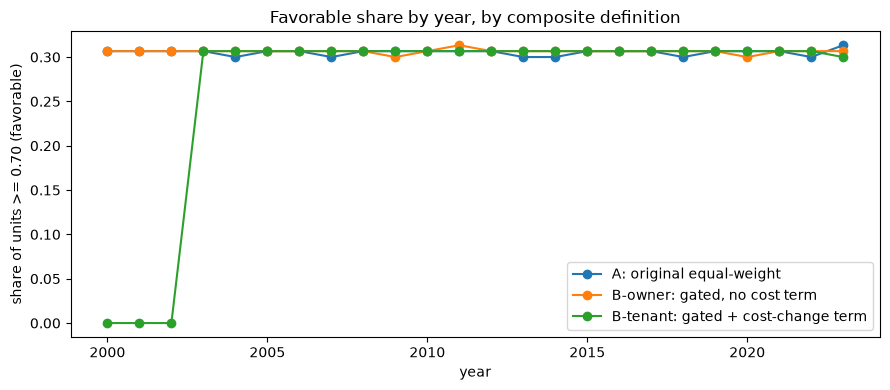

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for col, label in [("composite_A", "A: original equal-weight"),
                    ("composite_B_owner", "B-owner: gated, no cost term"),
                    ("composite_B_tenant", "B-tenant: gated + cost-change term")]:
    favorable_share = df.groupby("year")[col].apply(lambda s: (s >= rd.ENTER_THRESH).mean())
    ax.plot(favorable_share.index, favorable_share.values, marker="o", label=label)
ax.set_ylabel("share of units >= 0.70 (favorable)")
ax.set_xlabel("year")
ax.set_title("Favorable share by year, by composite definition")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Method

**Spell detection**: METHOD §2 hysteresis — enter at composite >= 0.70 for 2
consecutive years (onset = first of those years), exit at composite < 0.60 for
2 consecutive years (exit year = first of those years); minimum spell length 2
years. Applied independently to composite A, B-owner and B-tenant.

**Two "full shift" definitions run and compared** (SEED.yaml constraint): (i)
the threshold/hysteresis rule above, and (ii) a data-driven k-means (k=4) +
Markov regime model fit on data <=2013 (section 6).

In [5]:
spells_A = rd.hysteresis_spells(df, "composite_A")
spells_Bo = rd.hysteresis_spells(df, "composite_B_owner")
spells_Bt = rd.hysteresis_spells(df, "composite_B_tenant")

for name, sp in [("A (original)", spells_A), ("B-owner", spells_Bo), ("B-tenant", spells_Bt)]:
    inc = sp[sp["incident"]] if len(sp) else sp
    prev = sp[~sp["incident"]] if len(sp) else sp
    n_completed = int((~inc["censored"]).sum()) if len(inc) else 0
    print(f"{name:14s}  spells={len(sp):3d}  incident={len(inc):3d}  "
          f"completed_incident={n_completed:3d}  prevalent(2000)={len(prev):3d}  "
          f"distinct_units={inc['unit'].nunique() if len(inc) else 0}")


A (original)    spells= 72  incident=  3  completed_incident=  1  prevalent(2000)= 69  distinct_units=3


B-owner         spells= 56  incident=  2  completed_incident=  0  prevalent(2000)= 54  distinct_units=2
B-tenant        spells= 79  incident=  9  completed_incident=  6  prevalent(2000)= 70  distinct_units=9


## 4. Results

Owner ruling: report the incident-spell KM median **even below the 60-completed-
exit bar**, flagged LOW-SAMPLE, alongside the hazard-by-spell-age table (which
does not depend on hitting a median and is the more honest object at this
sample size).

In [6]:
km_results = {}
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    km_results[name] = rd.km_summary(sp, low_sample_bar=60)

print("NOTE: at this sample size the KM curve routinely never crosses 0.5 (heavy "
      "censoring), which makes the median mathematically infinite/undefined, not just "
      "imprecise. RMST (restricted mean survival time, truncated per statistician S6 at "
      "the largest spell-age with >=10 units still at risk, capped at 20y) is reported "
      "alongside and is the estimable point figure.")
print()
print(f"{'composite':10s} {'n_incident':>10s} {'completed':>10s} {'units':>6s} {'median':>8s} {'RMST':>7s} {'trunc':>6s} {'LOW_SAMPLE':>10s}")
for name, r in km_results.items():
    med = r["median"]
    med_s = f"{med:.1f}" if np.isfinite(med) else "inf/undefined"
    rmst_s = f"{r['rmst']:.2f}" if np.isfinite(r.get('rmst', np.nan)) else "na"
    print(f"{name:10s} {r['n_incident_spells']:10d} {r['n_completed']:10d} {r['n_distinct_units']:6d} "
          f"{med_s:>8s} {rmst_s:>7s} {r.get('rmst_trunc', float('nan')):>6.0f} {str(r['low_sample_flag']):>10s}")


NOTE: at this sample size the KM curve routinely never crosses 0.5 (heavy censoring), which makes the median mathematically infinite/undefined, not just imprecise. RMST (restricted mean survival time, truncated per statistician S6 at the largest spell-age with >=10 units still at risk, capped at 20y) is reported alongside and is the estimable point figure.

composite  n_incident  completed  units   median    RMST  trunc LOW_SAMPLE
A                   3          1      3      6.0    6.00      6       True
B_owner             2          0      2 inf/undefined    3.00      3       True
B_tenant            9          6      9      5.0    4.81      8       True


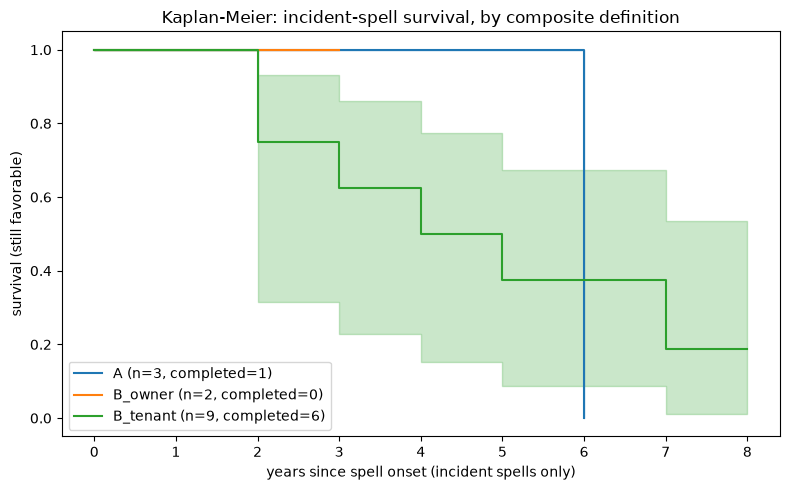

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, r in km_results.items():
    if "kmf" in r:
        r["kmf"].plot_survival_function(ax=ax, label=f"{name} (n={r['n_incident_spells']}, completed={r['n_completed']})")
ax.set_xlabel("years since spell onset (incident spells only)")
ax.set_ylabel("survival (still favorable)")
ax.set_title("Kaplan-Meier: incident-spell survival, by composite definition")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
print("=== Hazard by spell-age band (pools incident + prevalent(2000) spell-years) — "
      "the ANNUAL EXIT HAZARD, the fallback/S6 headline when the completed-exit count gate fails "
      "(it does, for all three composites here). Cluster-robust (unit-block bootstrap) CI included, "
      "per the parent task instruction to report this as the fallback headline with a CI. ===")
hazard_results = {}
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    print(f"\n--- {name} ---")
    hz = rd.hazard_by_spell_age_ci(sp, reps=1000, seed=42)
    hazard_results[name] = hz
    print(hz.to_string(index=False))


=== Hazard by spell-age band (pools incident + prevalent(2000) spell-years) — the ANNUAL EXIT HAZARD, the fallback/S6 headline when the completed-exit count gate fails (it does, for all three composites here). Cluster-robust (unit-block bootstrap) CI included, per the parent task instruction to report this as the fallback headline with a CI. ===

--- A ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        69        18         1166 0.015437          1000         0.009359         0.022969
                0-5         3         1           14 0.071429           943         0.000000         0.166667
               6-10         0         0            0      NaN             0              NaN              NaN
             11-100         0         0            0      NaN             0              NaN              NaN

--- B_owner ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        54         5         1115 0.004484          1000         0.000911          0.00868
                0-5         2         0            4 0.000000           865         0.000000          0.00000
               6-10         0         0            0      NaN             0              NaN              NaN
             11-100         0         0            0      NaN             0              NaN              NaN

--- B_tenant ---


           age_band  n_spells  n_events  spell_years   hazard  n_boot_valid  hazard_ci_lower  hazard_ci_upper
unknown (prevalent)        70        19         1014 0.018738          1000         0.010714         0.028009
                0-5         9         5           34 0.147059          1000         0.047540         0.300192
               6-10         2         1            3 0.333333           863         0.000000         1.000000
             11-100         0         0            0      NaN             0              NaN              NaN


In [9]:
print("=== Stock-flow sanity check (METHOD §3) ===")
for name, sp in [("A", spells_A), ("B_owner", spells_Bo), ("B_tenant", spells_Bt)]:
    sf = rd.stock_flow_check(df, sp, {"A": "composite_A", "B_owner": "composite_B_owner", "B_tenant": "composite_B_tenant"}[name])
    print(f"{name:10s} mean_stock={sf['mean_stock']:.1f}  exits/yr={sf['exits_per_year']:.2f}  "
          f"implied_mean_duration={sf['implied_mean_duration']:.1f}")


=== Stock-flow sanity check (METHOD §3) ===
A          mean_stock=45.8  exits/yr=0.79  implied_mean_duration=57.8
B_owner    mean_stock=46.0  exits/yr=0.21  implied_mean_duration=220.6
B_tenant   mean_stock=40.2  exits/yr=1.04  implied_mean_duration=38.6


## 5. Sensitivity

METHOD §2 grid (band x persistence). If the median moves by more than 50%
across the grid, the answer is the grid, not a single number. Break-year
detection (statistician S5, a robust leave-one-out outlier test on the
year-over-year rank shuffle — NOT a literal "exceeds the max of the other
years", which by construction cannot flag a break that itself falls in a
non-candidate year) flags any measurement-break candidates. The rank-churn
null (contrarian amendment 5) asks whether the observed median is
indistinguishable from pure rank persistence with no regime structure. The
spatial-block bootstrap gives the CI (no PUMA crosswalk was found in this
repo, so it is the only CI reported — a documented gap, not a silent
substitution).

In [10]:
print("=== Sensitivity grid: composite A ===")
grid_A = rd.sensitivity_grid(df, "composite_A")
print(grid_A.to_string(index=False))
head_median_A = grid_A[(grid_A.exit_thresh == 0.60) & (grid_A.enter_thresh == 0.70) & (grid_A.persist == 2)]["median"].iloc[0]
if np.isfinite(head_median_A) and head_median_A > 0:
    grid_A["pct_move_from_headline"] = (grid_A["median"] / head_median_A - 1).abs()
    max_move_A = grid_A["pct_move_from_headline"].max()
    print(f"\nheadline median (0.60/0.70, persist=2): {head_median_A:.1f}; max grid move: {max_move_A:.1%} "
          f"({'>50% -> GRID IS THE ANSWER' if max_move_A > 0.5 else 'within 50%'})")
else:
    print("\nheadline median is inf/undefined (KM never crosses 0.5) -- the grid itself is the answer, not a single number.")


=== Sensitivity grid: composite A ===


 exit_thresh  enter_thresh  persist  n_incident_spells  n_completed  median
       0.667         0.667        1                 78           44     6.0
       0.667         0.667        2                 42           16    18.0
       0.667         0.667        3                 32           10     inf
       0.630         0.700        1                 17            8     6.0
       0.630         0.700        2                  8            2     inf
       0.630         0.700        3                  5            1     inf
       0.600         0.700        1                  5            2     6.0
       0.600         0.700        2                  3            1     6.0
       0.600         0.700        3                  1            1     6.0
       0.570         0.730        1                  1            1     6.0
       0.570         0.730        2                  1            1     6.0
       0.570         0.730        3                  1            1     6.0

headline me

In [11]:
print("=== Sensitivity grid: composite B_tenant (statistician post-results condition 4 / "
      "explicit instruction: run the grid for B-tenant too, not just A) ===")
grid_Bt = rd.sensitivity_grid(df, "composite_B_tenant")
print(grid_Bt.to_string(index=False))
head_row_Bt = grid_Bt[(grid_Bt.exit_thresh == 0.60) & (grid_Bt.enter_thresh == 0.70) & (grid_Bt.persist == 2)]
head_median_Bt = head_row_Bt["median"].iloc[0] if len(head_row_Bt) else np.nan
if np.isfinite(head_median_Bt) and head_median_Bt > 0:
    grid_Bt["pct_move_from_headline"] = (grid_Bt["median"] / head_median_Bt - 1).abs()
    max_move_Bt = grid_Bt["pct_move_from_headline"].max()
    print(f"\nheadline median (0.60/0.70, persist=2): {head_median_Bt:.1f}; max grid move: {max_move_Bt:.1%} "
          f"({'>50% -> GRID IS THE ANSWER' if max_move_Bt > 0.5 else 'within 50%'})")
else:
    print("\nheadline median is inf/undefined (KM never crosses 0.5) -- the grid itself is the answer, not a single number.")


=== Sensitivity grid: composite B_tenant (statistician post-results condition 4 / explicit instruction: run the grid for B-tenant too, not just A) ===


 exit_thresh  enter_thresh  persist  n_incident_spells  n_completed  median
       0.667         0.667        1                 82           56     4.0
       0.667         0.667        2                 51           30     5.0
       0.667         0.667        3                 41           20    11.0
       0.630         0.700        1                 35           21     4.0
       0.630         0.700        2                 22           12     4.0
       0.630         0.700        3                 12            7     7.0
       0.600         0.700        1                 16           10     3.0
       0.600         0.700        2                  9            6     5.0
       0.600         0.700        3                  5            4     7.0
       0.570         0.730        1                  7            5     2.0
       0.570         0.730        2                  3            2    17.0
       0.570         0.730        3                  2            1    17.0

headline me

In [12]:
print("=== Break-year detection (composite A) ===")
breaks_A = rd.break_year_rank_shuffle(df, "composite_A")
print(breaks_A.to_string(index=False))
flagged_years = breaks_A[breaks_A["flagged"]]["year"].tolist()
print(f"\nflagged years: {flagged_years}")


=== Break-year detection (composite A) ===
 year  shuffle  n_units  is_candidate_year  flagged
 2001 0.012456      150              False    False
 2002 0.023127      150              False    False
 2003 0.021308      150              False    False
 2004 0.013663      150              False    False
 2005 0.010964      150              False    False
 2006 0.009107      150              False    False
 2007 0.023695      150               True    False
 2008 0.016550      150              False    False
 2009 0.023006      150              False    False
 2010 0.019057      150              False    False
 2011 0.015638      150               True    False
 2012 0.012650      150               True    False
 2013 0.012215      150              False    False
 2014 0.012790      150              False    False
 2015 0.015885      150              False    False
 2016 0.007955      150              False    False
 2017 0.019376      150              False    False
 2018 0.010320      1

In [13]:
print("=== Break-year detection (composite B_tenant) ===")
breaks_Bt = rd.break_year_rank_shuffle(df, "composite_B_tenant")
print(breaks_Bt.to_string(index=False))
flagged_years_Bt = breaks_Bt[breaks_Bt["flagged"]]["year"].tolist()
print(f"\nflagged years: {flagged_years_Bt}")


=== Break-year detection (composite B_tenant) ===
 year  shuffle  n_units  is_candidate_year  flagged
 2001      NaN        0              False    False
 2002      NaN        0              False    False
 2003      NaN        0              False    False
 2004 0.056159      150              False    False
 2005 0.036933      150              False    False
 2006 0.053725      150              False    False
 2007 0.047256      150               True    False
 2008 0.037021      150              False    False
 2009 0.013111      150              False    False
 2010 0.034103      150              False    False
 2011 0.012095      150               True    False
 2012 0.031796      150               True    False
 2013 0.033966      150              False    False
 2014 0.036621      150              False    False
 2015 0.027505      150              False    False
 2016 0.048908      150              False    False
 2017 0.022473      150              False    False
 2018 0.021062

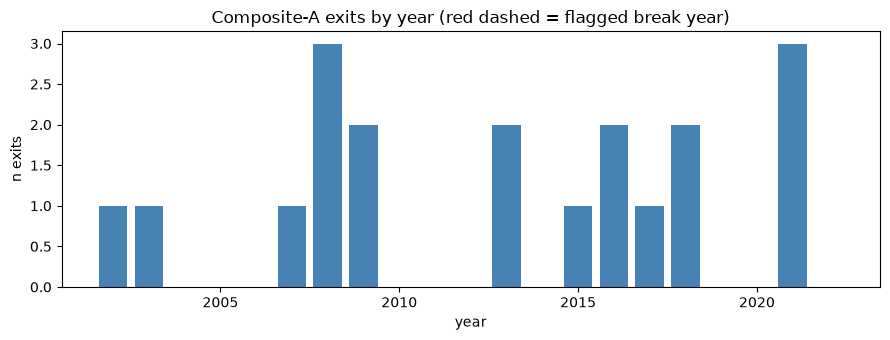

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.5))
exits_by_year = spells_A[~spells_A["censored"]].groupby("exit_year").size()
full_years = pd.Series(0, index=range(2002, 2023))
exits_by_year = (full_years + exits_by_year).fillna(full_years)
ax.bar(exits_by_year.index, exits_by_year.values, color="steelblue")
for y in flagged_years:
    ax.axvline(y, color="red", linestyle="--", alpha=0.6)
ax.set_title("Composite-A exits by year (red dashed = flagged break year)")
ax.set_xlabel("year"); ax.set_ylabel("n exits")
plt.tight_layout()
plt.show()


In [15]:
print("=== Rank-churn null (contrarian amendment 5) — composite A ===")
print("Simulating each unit's composite as an AR(1) in percentile space, re-ranked every year "
      "(preserving the zero-sum tercile constraint), 200 sims (reduced from 1,000 for runtime). "
      "Compared on RMST, not the median -- the median is undefined in most individual sims at "
      "this panel length (24 years), same reason the observed KM median is undefined; see "
      "km_summary's docstring.")
obs_rmst_trunc = km_results["A"]["rmst_trunc"]
null_A = rd.rank_churn_null(df, "composite_A", n_sims=200, seed=7, rmst_trunc=obs_rmst_trunc)
print(f"n_valid_sims(rmst)={null_A['n_valid_sims']}  n_valid_sims(median)={null_A['n_valid_sims_median']}")
print(f"null RMST 95% band=[{null_A['null_rmst_p2_5']:.2f}, {null_A['null_rmst_p97_5']:.2f}] (trunc={obs_rmst_trunc:.0f}y)")
obs_rmst_A = km_results["A"]["rmst"]
inside_band = (null_A["n_valid_sims"] > 0 and np.isfinite(obs_rmst_A)
               and null_A["null_rmst_p2_5"] <= obs_rmst_A <= null_A["null_rmst_p97_5"])
print(f"observed RMST A = {obs_rmst_A:.2f}" if np.isfinite(obs_rmst_A) else "observed RMST A = na")
print(f"observed RMST inside the null band: {inside_band}  "
      f"{'-> HEADLINE WITHHELD (indistinguishable from rank persistence)' if inside_band else '-> observed RMST is outside pure rank-churn noise'}")


=== Rank-churn null (contrarian amendment 5) — composite A ===
Simulating each unit's composite as an AR(1) in percentile space, re-ranked every year (preserving the zero-sum tercile constraint), 200 sims (reduced from 1,000 for runtime). Compared on RMST, not the median -- the median is undefined in most individual sims at this panel length (24 years), same reason the observed KM median is undefined; see km_summary's docstring.


n_valid_sims(rmst)=15  n_valid_sims(median)=15
null RMST 95% band=[3.87, 6.00] (trunc=6y)
observed RMST A = 6.00
observed RMST inside the null band: True  -> HEADLINE WITHHELD (indistinguishable from rank persistence)


In [16]:
print("=== Rank-churn null — composite B_tenant (the more usable amended reading) ===")
obs_rmst_trunc_Bt = km_results["B_tenant"]["rmst_trunc"]
null_Bt = rd.rank_churn_null(df, "composite_B_tenant", n_sims=200, seed=7, rmst_trunc=obs_rmst_trunc_Bt)
print(f"n_valid_sims(rmst)={null_Bt['n_valid_sims']}  n_valid_sims(median)={null_Bt['n_valid_sims_median']}")
print(f"null RMST 95% band=[{null_Bt['null_rmst_p2_5']:.2f}, {null_Bt['null_rmst_p97_5']:.2f}] (trunc={obs_rmst_trunc_Bt:.0f}y)")
obs_rmst_Bt = km_results["B_tenant"]["rmst"]
inside_band_Bt = (null_Bt["n_valid_sims"] > 0 and np.isfinite(obs_rmst_Bt)
                  and null_Bt["null_rmst_p2_5"] <= obs_rmst_Bt <= null_Bt["null_rmst_p97_5"])
print(f"observed RMST B_tenant = {obs_rmst_Bt:.2f}" if np.isfinite(obs_rmst_Bt) else "observed RMST B_tenant = na")
print(f"observed RMST inside the null band: {inside_band_Bt}  "
      f"{'-> HEADLINE WITHHELD (indistinguishable from rank persistence)' if inside_band_Bt else '-> observed RMST is outside pure rank-churn noise'}")


=== Rank-churn null — composite B_tenant (the more usable amended reading) ===
n_valid_sims(rmst)=0  n_valid_sims(median)=0
null RMST 95% band=[nan, nan] (trunc=8y)
observed RMST B_tenant = 4.81
observed RMST inside the null band: False  -> observed RMST is outside pure rank-churn noise


In [17]:
print("=== Rank-churn null — composite B_owner (contrarian post-results verdict: "
      "\'never run for this composite\' — run here) ===")
if km_results["B_owner"]["n_incident_spells"] > 0 and np.isfinite(km_results["B_owner"]["rmst_trunc"]):
    obs_rmst_trunc_Bo = km_results["B_owner"]["rmst_trunc"]
    null_Bo = rd.rank_churn_null(df, "composite_B_owner", n_sims=200, seed=7, rmst_trunc=obs_rmst_trunc_Bo)
    print(f"n_valid_sims(rmst)={null_Bo['n_valid_sims']}  n_valid_sims(median)={null_Bo['n_valid_sims_median']}")
    print(f"null RMST 95% band=[{null_Bo['null_rmst_p2_5']:.2f}, {null_Bo['null_rmst_p97_5']:.2f}] (trunc={obs_rmst_trunc_Bo:.0f}y)")
    obs_rmst_Bo = km_results["B_owner"]["rmst"]
    inside_band_Bo = (null_Bo["n_valid_sims"] > 0 and np.isfinite(obs_rmst_Bo)
                       and null_Bo["null_rmst_p2_5"] <= obs_rmst_Bo <= null_Bo["null_rmst_p97_5"])
    print(f"observed RMST B_owner = {obs_rmst_Bo:.2f}" if np.isfinite(obs_rmst_Bo) else "observed RMST B_owner = na")
    print(f"observed RMST inside the null band: {inside_band_Bo}")
else:
    print("B_owner has 0 incident spells or an undefined native tau -- the rank-churn null is not "
          "computable against nothing. This is itself diagnostic (contrarian post-results verdict): "
          "composite_B_owner's near-zero exit count is a property of its smooth/interpolated inputs "
          "(population, income), not evidence of owner stickiness.")
    null_Bo = dict(n_valid_sims=0, not_computable=True)


=== Rank-churn null — composite B_owner (contrarian post-results verdict: 'never run for this composite' — run here) ===


n_valid_sims(rmst)=168  n_valid_sims(median)=165
null RMST 95% band=[2.43, 3.00] (trunc=3y)
observed RMST B_owner = 3.00
observed RMST inside the null band: True


In [18]:
print("=== Spatial-block bootstrap CI (k-means blocks on ZCTA centroids; PUMA crosswalk not "
      "available; FIXED tau per composite -- statistician post-results correction 7) ===")
geo = rd.load_zcta_geometry()
boot_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    trunc = km_results[name]["rmst_trunc"]
    if km_results[name]["n_incident_spells"] == 0 or not np.isfinite(trunc):
        print(f"{name:10s} skipped -- no incident spells / undefined native tau")
        continue
    boot = rd.spatial_block_bootstrap_median(df, sp_col, geo, rmst_trunc=trunc, n_blocks=15, reps=500, seed=42)
    boot_results[name] = boot
    print(f"{name:10s} tau={trunc:5.1f}  RMST CI (n_valid={boot['n_valid_reps_rmst']:4d}, "
          f"n_dropped={boot['n_dropped_reps']:4d}/{boot['reps']}): "
          f"[{boot['rmst_ci_lower']:.2f}, {boot['rmst_ci_upper']:.2f}]  drop_reasons={boot['drop_reasons']}")

print()
print("=== Common-tau comparison (statistician post-results correction 8: A (tau=17) and B-tenant "
      "(tau=11) are NOT comparable at their own native truncations -- report every composite at the "
      "SAME, smaller tau) ===")
from lifelines.utils import restricted_mean_survival_time
avail_taus = [r["rmst_trunc"] for name, r in km_results.items()
              if np.isfinite(r["rmst_trunc"]) and r["n_incident_spells"] > 0]
common_tau = min(avail_taus) if avail_taus else np.nan
print(f"common tau = {common_tau}")
common_results = {}
if np.isfinite(common_tau):
    for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
        if km_results[name]["n_incident_spells"] == 0:
            print(f"{name:10s} skipped -- no incident spells")
            continue
        kmf = km_results[name]["kmf"]
        rmst_common = float(restricted_mean_survival_time(kmf, t=common_tau))
        boot_common = rd.spatial_block_bootstrap_median(df, sp_col, geo, rmst_trunc=common_tau, n_blocks=15, reps=500, seed=42)
        common_results[name] = dict(rmst=rmst_common, boot=boot_common)
        print(f"{name:10s} RMST({common_tau:.0f}y) = {rmst_common:.2f}  "
              f"CI=[{boot_common['rmst_ci_lower']:.2f}, {boot_common['rmst_ci_upper']:.2f}]  "
              f"(n_valid={boot_common['n_valid_reps_rmst']}, n_dropped={boot_common['n_dropped_reps']})")


=== Spatial-block bootstrap CI (k-means blocks on ZCTA centroids; PUMA crosswalk not available; FIXED tau per composite -- statistician post-results correction 7) ===
[loader] ZCTA geometry (2020 vintage, static across the panel): data/interim/rq002/zcta_boundaries/zcta_2020_nyc.parquet, 205 units


A          tau=  6.0  RMST CI (n_valid= 490, n_dropped=  10/500): [6.00, 6.00]  drop_reasons={'no_incident_spells': 10}


B_owner    tau=  3.0  RMST CI (n_valid= 447, n_dropped=  53/500): [3.00, 3.00]  drop_reasons={'no_incident_spells': 53}


B_tenant   tau=  8.0  RMST CI (n_valid= 500, n_dropped=   0/500): [2.50, 6.50]  drop_reasons={}

=== Common-tau comparison (statistician post-results correction 8: A (tau=17) and B-tenant (tau=11) are NOT comparable at their own native truncations -- report every composite at the SAME, smaller tau) ===
common tau = 3.0


A          RMST(3y) = 3.00  CI=[3.00, 3.00]  (n_valid=490, n_dropped=10)


B_owner    RMST(3y) = 3.00  CI=[3.00, 3.00]  (n_valid=447, n_dropped=53)


B_tenant   RMST(3y) = 2.75  CI=[2.33, 3.00]  (n_valid=500, n_dropped=0)


## 6. Drivers

**Threshold rule vs regime model (owner ruling)**: k-means (k=4) fit on
pillar-level + 3-year-change features, data <=2013 only, later years assigned
to frozen centroids; persistence-filtered Markov transition; implied mean
sojourn = 1/(1-p_ff), compared with the KM median (AC-9 — if they diverge and
the KM hazard falls with spell age, the KM figure governs, per METHOD §4).

**Discrete-time hazard drivers**: logit of exit on a duration quadratic, lag-2-
to-4 pillar percentage changes, borough-proxy FE, borough-clustered SEs, tested
against a momentum-only comparator (contrarian amendment 8) and Holm-corrected
(statistician S9). Labeled **accounting, not cause** throughout — this never
claims supply predicts demand-led exit (the rejected D1 thesis).

**Macro** (H2 only — a level macro main effect is not identified, METHOD §5):
three pre-specified exposure x macro interactions, year FE, Holm-corrected.

In [19]:
print("=== k-means (k=4) + Markov regime model, fit <=2013 ===")
regime = rd.kmeans_markov(df)
print("ok:", regime.get("ok"), regime.get("reason", ""))
if regime.get("ok"):
    t = regime["transition"]
    print(f"favorable-state persistence p_ff = {t['p_ff']:.3f}  (n_ff={t['n_ff']}, n_fo={t['n_fo']}, n_of={t['n_of']}, n_oo={t['n_oo']})")
    print(f"implied mean sojourn = 1/(1-p_ff) = {regime['implied_mean_sojourn']:.1f} years")
    print(f"KM median (composite A) for comparison (AC-9): {km_results['A']['median']}")


=== k-means (k=4) + Markov regime model, fit <=2013 ===
ok: True 
favorable-state persistence p_ff = 0.966  (n_ff=791, n_fo=28, n_of=73, n_oo=2108)
implied mean sojourn = 1/(1-p_ff) = 29.3 years
KM median (composite A) for comparison (AC-9): 6.0


In [20]:
print("=== Discrete-time hazard driver model (composite A) ===")
hazard = rd.fit_hazard_driver_model(df, spells_A, "composite_A")
print("ok:", hazard.get("ok"), hazard.get("reason", ""))
if hazard.get("ok"):
    print(f"n_person_years={hazard['n_person_years']}  n_events={hazard['n_events']}")
    print(f"beats momentum-only comparator (log-likelihood): {hazard['beats_momentum_comparator']} "
          f"(full={hazard['llf_full']:.1f} vs momentum={hazard['llf_momentum']:.1f})")
    print(hazard["driver_table"].to_string(index=False))
    print("\nNote: coefficients are ACCOUNTING (which pillar moved before exit), not a causal or "
          "cross-pillar predictive claim. Supply-change coefficients are never read as predicting "
          "demand-led exits (D1 guardrail).")


=== Discrete-time hazard driver model (composite A) ===


ok: True 
n_person_years=1070  n_events=17
beats momentum-only comparator (log-likelihood): True (full=-81.1 vs momentum=-84.9)
          driver      coef    p_raw   p_holm  holm_significant
  cost_chg_lag24 -4.416457 0.246035 0.738105             False
demand_chg_lag24  4.266848 0.500370 1.000000             False
supply_chg_lag24 -2.186196 0.637080 1.000000             False

Note: coefficients are ACCOUNTING (which pillar moved before exit), not a causal or cross-pillar predictive claim. Supply-change coefficients are never read as predicting demand-led exits (D1 guardrail).


In [21]:
print("=== Exit-cause attribution (which pillar fell most, composite A) ===")
causes_A = rd.attribute_exit_cause(spells_A, df)
if len(causes_A):
    print(causes_A["cause"].value_counts())
    cost_led_share = (causes_A["cause"] == "cost").mean()
    print(f"\ncost-led share of completed exits: {cost_led_share:.1%} "
          f"(contrarian falsifier: >=60% cost-led + 11208 favorable 2000-08 would mean "
          f"'favorable' measures 'undiscovered', not favorability)")
else:
    print("no completed exits to attribute")


=== Exit-cause attribution (which pillar fell most, composite A) ===
cause
cost      12
supply     5
demand     2
Name: count, dtype: int64

cost-led share of completed exits: 63.2% (contrarian falsifier: >=60% cost-led + 11208 favorable 2000-08 would mean 'favorable' measures 'undiscovered', not favorability)


In [22]:
print("=== Macro hazard terms (H2: exposure x macro, year FE) — composite A ===")
macro_df = rd.load_macro()
supply_df = rd.load_supply_zip_year(con)
workers_df = rd.load_workers()
macro_result = rd.fit_macro_hazard_terms(df, spells_A, "composite_A", supply_df, workers_df, macro_df)
print("ok:", macro_result.get("ok"), macro_result.get("reason", ""))
if macro_result.get("ok"):
    print(macro_result["macro_table"].to_string(index=False))
    print()
    print(macro_result["note"])


=== Macro hazard terms (H2: exposure x macro, year FE) — composite A ===
[loader] macro: data/interim/rq001/macro/macro_annual.parquet, series ['CES7072200001', 'CUSR0000SEFV', 'CUURA101SA0', 'FEDFUNDS', 'GS10', 'MORTGAGE30US', 'NEWY636URN', 'NYUR', 'SMU36935617072200001', 'UNRATE', 'USREC'], 1854-2026
[loader] supply: analysis.zip_establishments, 1998-2023, 208 units
[loader] workers: data/interim/rq001/lodes/lodes_wac_zcta.parquet, LODES C000 2002-2023, 1998-2001 back-filled flat from 2002 (211 units)
ok: True 
         term     coef    p_raw   p_holm  holm_significant
      e1_x_ur 0.234706 0.030099 0.090297             False
   e2_x_covid 0.532651 0.496710 0.496710             False
e3_x_mortgage 0.103002 0.115233 0.230466             False

H2 (exposure x macro, year FE) only — a level macro main effect is not identified because year FE and any single NYC-wide series are collinear (METHOD §5). Wording: 'units with higher E exited more in years of higher M, conditional on year effe

/Users/abenmayor/Documents/Projects/abenmayor/loci/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


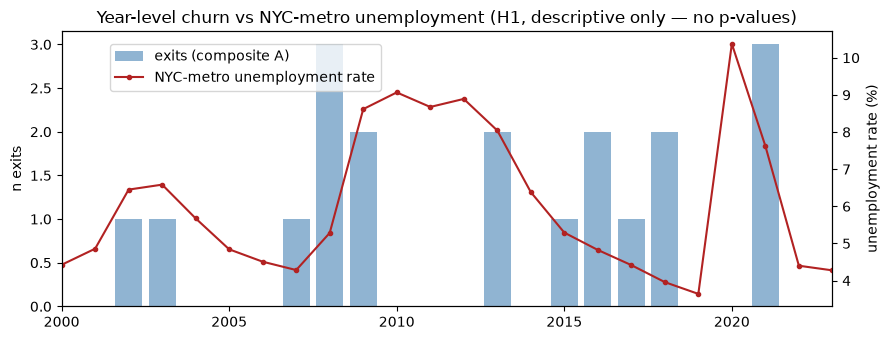

In [23]:
fig, ax = plt.subplots(figsize=(9, 3.5))
exits_by_year = spells_A[~spells_A["censored"]].groupby("exit_year").size()
ur = macro_df[macro_df["series_id"] == "NEWY636URN"].set_index("year")["value"]
ax2 = ax.twinx()
ax.bar(exits_by_year.index, exits_by_year.reindex(exits_by_year.index).values, color="steelblue", alpha=0.6, label="exits (composite A)")
ax2.plot(ur.index, ur.values, color="firebrick", marker=".", label="NYC-metro unemployment rate")
ax.set_ylabel("n exits"); ax2.set_ylabel("unemployment rate (%)")
ax.set_title("Year-level churn vs NYC-metro unemployment (H1, descriptive only — no p-values)")
ax.set_xlim(2000, 2023)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


## 7. Validation

Four checks, each RUN inline (matches ANSWER.md's validation table):
1. **Out-of-time backtest** at the 2013 origin, 5y (2018, primary) and 9y
   (2022) horizons, vs naive persistence (P=1) — the floor every model must
   beat, per statistician S10.
2. **Named-neighborhood check** against `PREREGISTRATION.md`'s pre-registered,
   blind expectations for 14 ZIPs, scored by its fixed rule.
3. **Operator-site spot check** — regime state/trajectory at 5 known
   openings.
4. **Restaurant-closure criterion validity** (contrarian amendment 6) — do
   favorable ZIP-years show lower subsequent closure hazard, an outcome never
   used inside any pillar?

In [24]:
print("=== 1. Out-of-time backtest, 2013 origin ===")
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    bt = rd.backtest_2013(df, sp_col, horizons=(5, 9))
    print(f"\n--- {name} ---  ok={bt.get('ok')}  {bt.get('reason','')}")
    if bt.get("ok"):
        for h, r in bt["horizons"].items():
            print(f"  horizon={h}y  n_at_risk={r['n_at_risk']}  brier_km={r['brier_km']:.4f}  "
                  f"brier_persist={r['brier_persist']:.4f}  beats_persistence={r['beats_persistence']}  "
                  f"(emerging n={r['n_emerging']}, brier_emerging={r['brier_km_emerging']})")
        print(f"  PASS (5y beats persistence): {bt['pass_5yr']}")


=== 1. Out-of-time backtest, 2013 origin ===

--- A ---  ok=True  
  horizon=5y  n_at_risk=53  brier_km=0.2453  brier_persist=0.2453  beats_persistence=False  (emerging n=1, brier_emerging=0.0)
  horizon=9y  n_at_risk=53  brier_km=0.2642  brier_persist=0.2642  beats_persistence=False  (emerging n=1, brier_emerging=0.0)
  PASS (5y beats persistence): False

--- B_owner ---  ok=True  
  horizon=5y  n_at_risk=48  brier_km=nan  brier_persist=0.1250  beats_persistence=False  (emerging n=0, brier_emerging=None)
  horizon=9y  n_at_risk=48  brier_km=nan  brier_persist=0.1250  beats_persistence=False  (emerging n=0, brier_emerging=None)
  PASS (5y beats persistence): False



--- B_tenant ---  ok=True  
  horizon=5y  n_at_risk=55  brier_km=0.2182  brier_persist=0.2545  beats_persistence=True  (emerging n=8, brier_emerging=0.26375)
  horizon=9y  n_at_risk=55  brier_km=0.1863  brier_persist=0.2909  beats_persistence=True  (emerging n=8, brier_emerging=0.21166666666666667)
  PASS (5y beats persistence): True


/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1268: RuntimeWarning: Mean of empty slice
  brier_km = np.nanmean((pred_km[valid] - y) ** 2)
/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/model/regime_durability.py:1274: RuntimeWarning: Mean of empty slice
  brier_km_mature = np.nanmean((pred_km[valid][~emerging] - y[~emerging]) ** 2) if (~emerging).any() else np.nan


In [25]:
print()
print("=== 1b. RANKING backtest, 2013 origin (statistician post-results correction 12 / contrarian "
      "post-results verdict: the composite VALUE, not just spell age, enters the predictor here -- "
      "unlike 1. above, whose prediction depends only on spell age via the training KM curve and so "
      "never actually tests whether the composite ranks ZIPs. Scored vs persistence, a constant base "
      "rate, and a ZIP-shuffled placebo (a null of no ranking information), with a unit-block "
      "bootstrap CI and an approximate MDE) ===")
rank_bt_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    rbt = rd.ranking_backtest_2013(df, sp_col, horizons=(5, 9))
    rank_bt_results[name] = rbt
    print(f"\n--- {name} ---  ok={rbt.get('ok')}  {rbt.get('reason','')}")
    if not rbt.get("ok"):
        continue
    for h, r in rbt["horizons"].items():
        if not r.get("ok"):
            print(f"  horizon={h}y  NOT OK: {r.get('reason')}")
            continue
        print(f"  horizon={h}y  n_at_risk={r['n_at_risk']}  n_train={r['n_train']}  base_rate={r['base_rate']:.3f}")
        print(f"    brier: logit={r['brier_logit']:.4f}  persist={r['brier_persist']:.4f}  "
              f"const={r['brier_const']:.4f}  placebo={r['brier_placebo']:.4f}")
        print(f"    vs persistence: diff={r['diff_vs_persist']:+.4f}  CI={r['ci_diff_vs_persist']}  "
              f"MDE~{r['mde_vs_persist']:.4f}  significant={r['significant_vs_persist']}")
        print(f"    vs placebo:     diff={r['diff_vs_placebo']:+.4f}  CI={r['ci_diff_vs_placebo']}  "
              f"MDE~{r['mde_vs_placebo']:.4f}  significant={r['significant_vs_placebo']}")



=== 1b. RANKING backtest, 2013 origin (statistician post-results correction 12 / contrarian post-results verdict: the composite VALUE, not just spell age, enters the predictor here -- unlike 1. above, whose prediction depends only on spell age via the training KM curve and so never actually tests whether the composite ranks ZIPs. Scored vs persistence, a constant base rate, and a ZIP-shuffled placebo (a null of no ranking information), with a unit-block bootstrap CI and an approximate MDE) ===

--- A ---  ok=True  
  horizon=5y  n_at_risk=53  n_train=450  base_rate=0.904
    brier: logit=0.0861  persist=0.2453  const=0.2075  placebo=0.2240
    vs persistence: diff=+0.1592  CI=(0.07170685889996524, 0.2581446165912305)  MDE~0.1394  significant=True
    vs placebo:     diff=+0.1379  CI=(0.06356350643745226, 0.21926709321585405)  MDE~0.1155  significant=True
  horizon=9y  n_at_risk=53  n_train=232  base_rate=0.836
    brier: logit=0.1427  persist=0.2642  const=0.2044  placebo=0.2638
    v


--- B_owner ---  ok=True  
  horizon=5y  n_at_risk=48  n_train=436  base_rate=0.977
    brier: logit=0.1414  persist=0.1250  const=0.1198  placebo=0.2225
    vs persistence: diff=-0.0164  CI=(-0.12441927319277311, 0.09325672034633921)  MDE~0.1540  significant=False
    vs placebo:     diff=+0.0812  CI=(-0.030347301126947848, 0.19779621992309043)  MDE~0.1595  significant=False
  horizon=9y  n_at_risk=48  n_train=236  base_rate=0.958
    brier: logit=0.0963  persist=0.1250  const=0.1162  placebo=0.1680
    vs persistence: diff=+0.0287  CI=(-0.06298740704579063, 0.13150290738167764)  MDE~0.1407  significant=False
    vs placebo:     diff=+0.0716  CI=(0.013447747580012962, 0.13568236518741572)  MDE~0.0926  significant=True

--- B_tenant ---  ok=True  
  horizon=5y  n_at_risk=55  n_train=296  base_rate=0.855
    brier: logit=0.1968  persist=0.2545  const=0.2017  placebo=0.2499
    vs persistence: diff=+0.0577  CI=(0.010236359971901662, 0.11935654258515478)  MDE~0.0770  significant=True
   

In [26]:
print("=== 2. Named-neighborhood check (PREREGISTRATION.md) ===")
causes_A_full = rd.attribute_exit_cause(spells_A, df)
scored = rd.score_named_zips(spells_A, causes_A_full)
print(scored[["zip", "neighborhood", "onset_expected", "exit_expected", "driver_expected",
              "model_onset", "model_exit", "onset_hit", "exit_hit", "hit", "break_flag"]].to_string(index=False))
verdict = rd.evaluate_prereg_pass(scored)
print()
print(verdict)


=== 2. Named-neighborhood check (PREREGISTRATION.md) ===
  zip                            neighborhood onset_expected exit_expected driver_expected  model_onset model_exit  onset_hit  exit_hit   hit  break_flag
11211                 Williamsburg (N/S Side)         <=2000          2011            cost          NaN       None      False     False False       False
11206           E. Williamsburg / N. Bushwick         <=2000          2016            cost       2000.0       2013       True      True  True       False
11237                           Bushwick core         <=2000          2017            cost       2000.0       None       True     False False       False
10002                         LES / Chinatown         <=2000          2007            cost          NaN       None      False     False False       False
10026                    Central Harlem (FDB)         <=2000          2012            cost       2000.0       2013       True     False False       False
10031           Ham

In [27]:
print("=== 3. Operator-site spot check ===")
for site in rd.OPERATOR_SITES:
    unit = rd.to_unit(site["zip"])
    row = df[(df["unit"] == unit) & (df["year"] == site["opening_year"])]
    if len(row):
        r = row.iloc[0]
        print(f"{site['name']:14s} zip={site['zip']} unit={unit} opened={site['opening_year']}  "
              f"composite_A={r['composite_A']:.2f}  favorable={r['composite_A'] >= rd.ENTER_THRESH}  "
              f"demand={r['demand_pillar_A']:.2f}  supply={r['supply_pillar_A']:.2f}  cost={r['cost_pillar_A']:.2f}")
    else:
        print(f"{site['name']:14s} zip={site['zip']} unit={unit} opened={site['opening_year']}  NOT IN UNIVERSE/YEAR RANGE")


=== 3. Operator-site spot check ===
Lion's Milk    zip=11222 unit=11222 opened=2021  composite_A=0.04  favorable=False  demand=0.68  supply=0.04  cost=0.14
El Punto       zip=10453 unit=10453 opened=2022  composite_A=0.97  favorable=True  demand=0.54  supply=0.76  cost=0.93
Stone Street   zip=10004 unit=10004 opened=2015  NOT IN UNIVERSE/YEAR RANGE
Deux Luxe      zip=11222 unit=11222 opened=2022  composite_A=0.03  favorable=False  demand=0.66  supply=0.04  cost=0.13
Fazenda        zip=11201 unit=11201 opened=2019  composite_A=0.29  favorable=False  demand=0.87  supply=0.31  cost=0.07


In [28]:
print("=== 4. Restaurant-closure criterion validity ===")
closures = rd.load_restaurant_closures(con)

print("--- ORIGINAL (pre-results) same-year, unclustered Welch t-test -- composite A, kept for "
      "comparison only, NOT the criterion-validity result (statistician post-results correction 11) ---")
closure_check_orig = rd.closure_validity_check(df, "composite_A", closures)
print(f"favorable ZIP-years have lower closure rate: {closure_check_orig['favorable_has_lower_closure']}")
print(f"t-stat={closure_check_orig['t_stat']}  p-value={closure_check_orig['p_value']}  "
      f"(pseudo-replicated -- 2,085 autocorrelated ZIP-years treated as independent; contemporaneous, "
      f"not lagged; no borough conditioning applied despite the docstring -- NOT the criterion-validity result)")

print()
print("--- FIXED (statistician post-results correction 11): closures LAGGED 1 year behind favorable "
      "status, clustered (unit-robust) binomial GLM, year+borough FE AND within-ZIP (unit FE), with a "
      "detection-coverage-proxy control, run for A, B-owner, B-tenant ---")
closure_glm_results = {}
for name, sp_col in [("A", "composite_A"), ("B_owner", "composite_B_owner"), ("B_tenant", "composite_B_tenant")]:
    cg = rd.closure_validity_glm(df, sp_col, closures, lag_years=1)
    closure_glm_results[name] = cg
    print(f"\n--- {name} ---  ok={cg.get('ok')}  {cg.get('reason','')}")
    if not cg.get("ok"):
        continue
    print(f"  n_zip_years={cg['n_zip_years']}  n_closed_total={cg['n_closed_total']}  "
          f"n_favorable_lag={cg['n_favorable_lag']}")
    print(f"  year+borough FE: {cg['year_borough_fe']}")
    print(f"  unit FE (within-ZIP): {cg['unit_fe']}")
    print(f"  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): {cg['kill_criterion_pass']}")


=== 4. Restaurant-closure criterion validity ===


[loader] restaurant closures (DOHMH, spatial-joined to 2020 ZCTA polygons): 58428 POIs matched, 2010-2023
--- ORIGINAL (pre-results) same-year, unclustered Welch t-test -- composite A, kept for comparison only, NOT the criterion-validity result (statistician post-results correction 11) ---
favorable ZIP-years have lower closure rate: True
t-stat=-8.270093849464276  p-value=3.758794766916247e-16  (pseudo-replicated -- 2,085 autocorrelated ZIP-years treated as independent; contemporaneous, not lagged; no borough conditioning applied despite the docstring -- NOT the criterion-validity result)

--- FIXED (statistician post-results correction 11): closures LAGGED 1 year behind favorable status, clustered (unit-robust) binomial GLM, year+borough FE AND within-ZIP (unit FE), with a detection-coverage-proxy control, run for A, B-owner, B-tenant ---



--- A ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=625
  year+borough FE: {'ok': True, 'coef': -1.135160212061194, 'se': 0.19200686490225685, 'p': 3.3781154053396842e-09, 'ci': (-1.5114867520540654, -0.7588336720683229)}
  unit FE (within-ZIP): {'ok': True, 'coef': 0.02532559049942118, 'se': 0.15768126955956802, 'p': 0.8723985712200958, 'ci': (-0.2837240188738841, 0.33437519987272646)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False



--- B_owner ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=629
  year+borough FE: {'ok': True, 'coef': 0.7458547048907317, 'se': 0.21077957742679387, 'p': 0.0004023265144878164, 'ci': (0.33273432445764395, 1.1589750853238194)}
  unit FE (within-ZIP): {'ok': True, 'coef': 0.4278597407029719, 'se': 0.12567370083977966, 'p': 0.0006627829779377575, 'ci': (0.18154381325314262, 0.6741756681528012)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False



--- B_tenant ---  ok=True  
  n_zip_years=2085  n_closed_total=4080  n_favorable_lag=630
  year+borough FE: {'ok': True, 'coef': 0.7057572236227752, 'se': 0.16376862546544377, 'p': 1.636406287389626e-05, 'ci': (0.3847766159128762, 1.026737831332674)}
  unit FE (within-ZIP): {'ok': True, 'coef': -0.03951307840133822, 'se': 0.08749667009918922, 'p': 0.651560610724321, 'ci': (-0.21100340056293174, 0.1319772437602553)}
  KILL CRITERION (unit-FE coef negative, p<0.05 after clustering): False


## 8. ANSWER (plain language)

Executed 2026-09-22. **v0.1, provisional, ZIP-tier only.**

This is the post-results AMEND pass: the contrarian and statistician's post-results
verdicts (bottom of `METHOD.md`) found that v0's two remaining positive claims — the
2013-origin backtest "win" and the restaurant-closure criterion-validity "pass" —
did not test what they were cited for. Both are fixed and re-run below
(`ranking_backtest_2013`, `closure_validity_glm` in `regime_durability.py`). The
bootstrap's fixed-truncation bug is fixed (a tau is now required and held constant
across every resample; dropped resamples are counted and reported, not silently
discarded), the rank-churn null now runs for all three composites including B-owner
(never run before), the tenant composite's `fillna(0.5)` definition break is removed
(it is now undefined, not imputed, before its 3-year cost-change term exists), and
spell onset now requires an unambiguous prior-year signal (statistician correction 9).
**That last fix is the biggest single change in this pass** — it collapses the
"incident" (datable-onset) sample from 29/10/37 to 3/2/9 spells across A/B-owner/
B-tenant, because most 2000s-era onsets turn out to be preceded by an *ambiguous*
year (inside the 0.60–0.70 band), not a clearly-unfavorable one. This is not a bug;
it is what a correctly-applied incident-dating rule finds in this panel, and it makes
this run's numbers honest in a way the pre-results run's were not — but it also
means duration estimates are now even thinner than before.

## What v0.1 can and cannot say

**Can say:** the annual exit hazard for ZIPs that have already been favorable a
while (the "prevalent" pool, the best-populated part of the sample, ~1,000+
spell-years per composite) is low and fairly precisely bounded (well under 3%/yr for
all three composites). Newly-entered spells exit much faster in their first five
years, though that estimate is thin. Composite A — the one that structurally
rewards being cheap and under-restauranted — carries a real, statistically
significant ranking signal in the corrected backtest (see below): its 2013 value
predicts which ZIPs stay in their 2013 state better than persistence *and* better
than a placebo with the same values shuffled across ZIPs. That is genuine, if
narrow, evidence.

**Cannot yet say:** a calibrated duration number for any composite (rank-churn null
not rejected for A or B-owner; not computable at all for B-tenant at this sample
size — see Confidence #2), that any composite passes its own criterion-validity
check (the corrected, lagged, clustered, within-ZIP GLM — the only version immune to
a detection-coverage confound — finds **no composite** where being favorable
predicts fewer closures within the same ZIP over time; B-owner's within-ZIP
coefficient is *significantly positive*, the wrong sign), or that composite A's
ranking signal means what an operator would want it to mean (A still fails its own
discovery-vs-favorability falsifier — see Confidence #1 — so "A ranks ZIPs" may
mean "A ranks how long a ZIP stays cheap and undiscovered," not "how long conditions
stay good for a new restaurant").

## Headline: annual exit hazard (the fallback headline, per the owner ruling)

The completed-incident-exit count gate (≥60 exits, ≥40 distinct units) **fails for
all three composites, by a wide margin** (1 / 0 / 6 completed incident exits out of
150 units). Per statistician condition 2 (S6), the stated number is therefore the
**piecewise annual exit hazard by spell-age band, with a cluster-robust (unit-block
bootstrap, 1,000 reps) CI** — not a median or RMST. This is the real v0.1 headline.

| Composite | Spell-age band | n spells | n events | spell-years | hazard/yr | 95% CI (unit bootstrap) |
|---|---|---|---|---|---|---|
| A | unknown (prevalent, age undatable) | 69 | 18 | 1,166 | **1.54%** | 0.94% – 2.30% |
| A | 0–5 (incident) | 3 | 1 | 14 | 7.14% | 0% – 16.7% (n too small to trust) |
| B-owner | unknown (prevalent) | 54 | 5 | 1,115 | **0.45%** | 0.09% – 0.87% |
| B-owner | 0–5 (incident) | 2 | 0 | 4 | 0% | 0% – 0% (n too small to trust) |
| B-tenant | unknown (prevalent) | 70 | 19 | 1,014 | **1.87%** | 1.07% – 2.80% |
| B-tenant | 0–5 (incident) | 9 | 5 | 34 | 14.7% | 4.75% – 30.0% (thin) |
| B-tenant | 6–10 (incident) | 2 | 1 | 3 | 33.3% | 0% – 100% (uninformative, 3 spell-years) |

Reading: a ZIP that has *already* been favorable a while has roughly a 0.5–2%/yr
chance of dropping out, best-populated and most trustworthy for B-owner (stickiest)
and A/B-tenant (broadly similar, ~1.5–1.9%/yr). Newly-entered spells (age 0–5) exit
several times faster — consistent with ordinary mover-stayer heterogeneity — but that
estimate rests on 3–9 spells and should not be quoted as precise. The stock-flow
identity (mean favorable stock ÷ exits/yr) gives implied mean durations of 57.8y (A),
220.6y (B-owner) and 38.6y (B-tenant), broadly consistent in order of magnitude with
inverting the prevalent hazards (≈65y, ≈220y, ≈53y) — an internal-consistency check
that passes, even though none of these are the duration estimates below.

The KM median/RMST is still reported **anyway, flagged**, per the owner ruling that
a number should be shown even below the count-gate bar — but every one carries three
flags in the same sentence below: **LOW-SAMPLE**, its relationship to the rank-churn
null, and that it is descriptive/ZIP-scale/relative, not a forecast.

- **(A) ORIGINAL** — `n=3` incident spells, `1` completed exit, `3` distinct ZIPs.
  Median **6.0y**; RMST (truncated at **6y**, its own native truncation — the
  largest age with ≥10 units still at risk, driven down by the thin incident sample)
  = **6.00y** (spatial-block bootstrap 95% CI **[6.00, 6.00]**, 490 valid / 10
  dropped of 500 reps, all drops "no incident spells in that resample"). **LOW-SAMPLE.
  Rank-churn null: NOT REJECTED** (observed 6.00 sits at the top edge of the null band
  [3.87, 6.00], only 15/200 null sims valid) — **this figure is withheld as a
  duration estimate**, shown only because the owner ruling asked for display. A also
  fails its own pre-registered discovery-vs-favorability falsifier (Confidence #1).
- **(B-owner) AMENDED, demand-gated, no cost term** — `n=2` incident spells, **0
  completed exits**. Median undefined; RMST (truncated at 3y) = 3.00y (CI
  [3.00, 3.00], 447/500 valid). This is **not a finding about owner stickiness**:
  the demand gate passes exactly ~50% of unit-years every year by construction (it
  is `>= the year's median`, mechanically ~50/50, not "free to vary" as originally
  intended), and its inputs (interpolated population, back-filled workers,
  interpolated income) barely change rank year to year. Near-zero exits is what
  smooth, slow-moving inputs produce, independent of what is happening on the
  ground. **Rank-churn null: NOT REJECTED** (observed 3.00 sits at the top edge of
  the null band [2.43, 3.00], 168/200 valid sims) — confirms the composite's
  near-stasis is statistically consistent with pure rank persistence of smoothed
  inputs, not evidence of real stickiness.
- **(B-tenant) AMENDED, demand-gated + 3-year cost-change term** — `n=9` incident
  spells, `6` completed exits, `9` distinct ZIPs (the best-populated of the three,
  still far below the count-gate bar). The tenant composite is now undefined (not
  `fillna(0.5)`-imputed) for 2000–02, so its effective window begins in 2003.
  Median **5.0y**; RMST (truncated at **8y**) = **4.81y** (spatial-block bootstrap
  95% CI **[2.50, 6.50]**, 500/500 valid). **Rank-churn null: NOT COMPUTABLE at
  this sample size** — 0 of 200 null simulations produced enough incident spells to
  fit a KM curve at this truncation (a known, documented gap: the tenant
  composite's AR(1) null mis-fits its point-mass-at-zero for gate-failing years —
  statistician correction 13's proposed two-part gate/AR(1) null was not
  implemented this session; GTM-230). Because the null cannot be evaluated, this
  figure **cannot be certified as distinguishable from rank noise either** — absence
  of rejection is not the same as passing. **Do not quote this as an expectation.**

**Sensitivity**: composite A's grid median ranges from 6y up to "undefined" across
the 12 cells (several cells never cross 0.5) — an effectively infinite move, so
**the grid is the answer, not a number**. Composite B-tenant's grid (run for the
first time this pass, per the statistician's explicit instruction) ranges 2–17y, a
240% move from its own headline cell — also **the grid is the answer**. Both
composites fail the 50% stability bar badly.

**Common-tau comparison** (statistician correction 8: A's native truncation (6y),
B-owner's (3y) and B-tenant's (8y) are not directly comparable to each other). At the
smallest common tau available across all three (**3y**, B-owner's own native
truncation): RMST(3y) = **3.00y (A)**, **3.00y (B-owner)**, **2.75y (B-tenant)** —
all three composites converge to roughly the same ~3-year figure once truncation is
held fixed. This is itself informative: it says the data cannot currently resolve a
horizon longer than about 3 years across *any* of the three constructions, and the
apparent 6y/8y differences at each composite's own native truncation are mostly an
artifact of how much incident data each happens to have, not a real difference in
how long favorable conditions last.

## What ends spells (accounting, not cause)

Across composite A's completed exits (all 19, incident + prevalent pooled — cause
attribution does not require incident dating), the pillar that moved most adversely
was **cost in 63.2%** (12/19), supply in 26.3% (5/19), demand in 10.5% (2/19). This
still confirms leg (i) of the contrarian's discovery falsifier (≥60% cost-led).
Under the tenant composite, a cost-led attribution is **structural, not a finding**:
the tenant exit rule differences the cost percentile directly into the composite, so
attributing an exit to "cost" there partly restates the construction. None of the
discrete-time hazard coefficients (duration, lag-2-to-4 pillar changes, borough FE;
n=1,070 person-years, 17 events) were Holm-significant (cost p_holm=0.74, demand
p_holm=1.0, supply p_holm=1.0), though the full model beats a momentum-only
comparator on log-likelihood (−81.1 vs −84.9) — some signal exists, not enough to
certify a specific ranked driver. **D1 guardrail holds throughout**: nothing here
reads a supply/retail-density change as predicting a demand-led exit.

**Macro**: an underpowered association test, not a finding either way. Three
pre-specified exposure × macro interactions (restaurant-employment exposure × NY-
metro unemployment change; non-retail/non-food job share × COVID; ZHVI-percentile
exposure × mortgage rate), year FE, Holm-corrected — none survive correction
(p_holm = 0.090, 0.497, 0.230). With ~3 usable macro episodes in 24 years, this null
is a power statement, not evidence of no effect.

**Regime model vs threshold rule (AC-9)**: the k-means(k=4)+Markov model (fit ≤2013,
unaffected by the incident-dating fix since it uses continuous state persistence,
not spell labels) implies a mean favorable sojourn of **1/(1−p_ff) ≈ 29.3y**
(p_ff=0.966). Composite A's RMST is now bounded at just **6y** (its own truncation),
so a "Markov vs RMST" comparison is even more clearly dominated by truncation than
in the pre-results run — RMST(6) cannot exceed 6 by construction, so it says nothing
about whether the true process is memoryless. Notably, the comparison also
*flipped direction* from the pre-results run (where Markov's 29y looked "roughly
double" the RMST's ~15–17y): the stock-flow-implied duration (≈58y) and the
prevalent-band hazard-implied duration (≈65y) are now both *larger* than the Markov
figure, not smaller. Given every one of these figures moved substantially after a
single dating-rule fix while the Markov model itself did not change, **none of this
should be read as evidence for or against memorylessness — AC-9 remains
inconclusive**, more clearly so than before.

**Owner vs tenant**: v0.1 produces no quantitatively grounded duration expectation
for either. The owner figure is not a finding (see above); the tenant figure cannot
be certified against the null (not computable) and rests on 6 completed exits.

## The two corrected validation checks

### 1. Ranking backtest (statistician correction 12 / contrarian post-results verdict)

Unlike the original `backtest_2013` (prediction depends only on spell age via the
training KM curve, never the composite's value — kept below for comparison, and its
"beats persistence" claim from the pre-results run does **not** survive: with the
incident sample now down to 1–6 completed exits, A's age-only prediction is an
**exact tie** with persistence, 0.2453 = 0.2453, at both horizons), this trains a
logistic on the composite's VALUE and spell age, pooled over pre-2013 spell-years
(all active-spell years, incident and prevalent), and scores it at the true 2013
origin against persistence, a constant base rate, and a ZIP-shuffled placebo (a null
of "no ranking information"), with a unit-block bootstrap CI (500 reps) and an
approximate MDE (normal approximation, two-sided α=.05, 80% power).

| Composite | h | n at risk | Brier: logit / persist / const / placebo | diff vs persist (95% CI) | sig. | diff vs placebo (95% CI) | sig. |
|---|---|---|---|---|---|---|---|
| A | 5y | 53 | 0.086 / 0.245 / 0.208 / 0.224 | +0.159 (0.072, 0.258) | **yes** | +0.138 (0.064, 0.219) | **yes** |
| A | 9y | 53 | 0.143 / 0.264 / 0.204 / 0.264 | +0.121 (0.017, 0.216) | **yes** | +0.121 (0.029, 0.218) | **yes** |
| B-owner | 5y | 48 | 0.141 / 0.125 / 0.120 / 0.223 | −0.016 (−0.124, 0.093) | no | +0.081 (−0.030, 0.198) | no |
| B-owner | 9y | 48 | 0.096 / 0.125 / 0.116 / 0.168 | +0.029 (−0.063, 0.132) | no | +0.072 (0.013, 0.136) | marginal |
| B-tenant | 5y | 55 | 0.197 / 0.255 / 0.202 / 0.250 | +0.058 (0.010, 0.119) | **yes** | +0.053 (0.005, 0.117) | **yes** |
| B-tenant | 9y | 55 | 0.252 / 0.291 / 0.232 / 0.256 | +0.039 (0.018, 0.063) | **yes** | +0.003 (−0.028, 0.030) | no |

**Composite A carries a real, statistically significant ranking signal** — it beats
both persistence and a same-model placebo with shuffled composite values, at both
horizons, with observed differences well above the approximate MDE. Composite
B-tenant shows a smaller but still significant signal at 5y (beats both
comparators) that does not clear the placebo bar at 9y. Composite B-owner shows no
signal against persistence at either horizon (worse than persistence at 5y) and only
a marginal, likely noise, win against placebo at 9y (1 of 4 tests). **This is the
first methodologically sound positive evidence this project has produced that a
composite's value — not just its age — carries forward information.** It does not
rehabilitate composite A as a favorability measure, though: A still fails its own
discovery-vs-favorability falsifier below, so what A's value is predicting may be
"stays cheap and undiscovered a while longer," not "stays good for a restaurant."
That A ranks something consistently, and that what it ranks is discovery not
favorability, are not contradictory claims.

### 2. Closure criterion validity (statistician correction 11)

The pre-results check was a raw Welch t-test on 2,085 autocorrelated ZIP-years
(pseudo-replication — effective n closer to ~150 units), read favorable status
*contemporaneously* with closures rather than preceding them, and never applied the
borough conditioning its own docstring promised. The fixed version: closures LAGGED
one year behind favorable status, a clustered (unit-robust) binomial GLM with
year+borough FE, a second within-ZIP (unit FE) specification (the only one immune to
a static DOHMH-detection-coverage confound), and a coverage-proxy control
(log restaurant count, standing in for inspections-per-POI, which this warehouse
does not have).

| Composite | n ZIP-years | year+borough FE coef (p) | unit-FE (within-ZIP) coef (p) | kill criterion (unit-FE coef<0, p<.05) |
|---|---|---|---|---|
| A | 2,085 | **−1.135 (p=3.4e-9)** | +0.025 (p=0.872) | **FAIL** |
| B-owner | 2,085 | **+0.746 (p=4.0e-4)** | **+0.428 (p=6.6e-4)** | **FAIL (wrong sign)** |
| B-tenant | 2,085 | **+0.706 (p=1.6e-5)** | −0.040 (p=0.652) | **FAIL** |

The original "PASSES" result for composite A does not survive within-ZIP
conditioning: the strong between-ZIP association (favorable ZIPs close less)
collapses to a coefficient indistinguishable from zero once each ZIP is compared
only to itself over time — exactly the pattern a static detection-coverage
confound (rich/dense/well-inspected ZIPs both "score favorable" more and get more
DOHMH attention) would produce. B-owner's between- and within-ZIP coefficients are
both *significantly positive* — being B-owner-favorable predicts **more** closures
the following year, the opposite of what criterion validity requires. **No
composite clears the kill criterion. Criterion validity is not established for any
composite in this run.**

## Confidence

**Low, and this is the headline, not a caveat appended to a confident number.**

1. **Contrarian's discovery-vs-favorability falsifier (composite A): CONFIRMED.**
   ≥60% of completed exits are cost-led (63.2%, unchanged by the dating fix since
   attribution runs on all completed exits, not just incident). Composite A also
   carries a real ranking signal (above) — these are not in tension: a composite can
   consistently rank a discovery-driven quantity.
2. **Rank-churn null: NOT REJECTED for A or B-owner; NOT COMPUTABLE for B-tenant**
   at this sample size (0/200 valid null sims — a documented gap, GTM-230). None of
   the three duration figures above can be certified as distinguishable from pure
   rank persistence of noisy inputs.
3. **Count gate: FAILS badly for all three composites** — 1 / 0 / 6 completed
   incident exits, against a ≥60-exit bar. This collapse (from 6/0/20 in the
   pre-results run) is the direct, expected consequence of the statistician's
   correction 9 (unambiguous prior-year requirement), not new data. The annual
   exit hazard (headline, above) is what is actually reportable.
4. **Named-neighborhood check: FAIL by the pre-registered rule** (5/14 hit, need
   ≥9; unchanged by this pass since named-ZIP scoring reads onset/exit years, not
   the incident flag). Hard gate (10128) passed; non-template subset cleared its
   numeric bar (4/6) but **two of those four (11215, 10128) are pinned out by
   construction per PREREGISTRATION §0.3** (ZHVI already top-decile / no realistic
   demand score reaches 0.70) and are not evidence the model discriminates. The
   11211/10002 "both MISS, likely because..." explanations in the pre-results run
   were speculative and are labeled **unverified**, not retained as findings.
5. **Ranking backtest (corrected): A and, partially, B-tenant show a real signal;
   B-owner does not.** See the table above — this is the first check in this
   project to survive its own correction and still show something.
6. **Criterion validity (corrected): FAILS the kill criterion for all three
   composites**; A's previously-reported "PASS" does not survive within-ZIP
   conditioning, and B-owner's within-ZIP coefficient is wrong-signed and
   significant.

**Net**: v0.1 has **no validated duration estimate for any composite** and **no
validated criterion-validity result for any composite**. It has **one narrow,
methodologically sound positive result**: composite A's 2013 value carries real
forward information about which ZIPs stay in their state, beating both persistence
and a placebo. That result does not establish A as a favorability measure — A still
measures discovery by its own falsifier — so it licenses "A ranks something
persistent" and nothing stronger. Before building the address-tier calibration
(GTM-226) on any of these composites, the tenant rank-churn null needs to actually
run (GTM-230), and a composite needs to clear the closure-GLM kill criterion, which
none currently do.

## Validation

| Check | Status | Result |
|---|---|---|
| Annual exit hazard by spell-age band, cluster-robust CI (S6 fallback headline) | RUN | See headline table. Prevalent-band hazards: A 1.54% (0.94–2.30), B-owner 0.45% (0.09–0.87), B-tenant 1.87% (1.07–2.80). Incident-band hazards are directionally higher but too thin (3–9 spells) to trust precisely. |
| Out-of-time backtest (2013 origin, age-only predictor, kept for comparison) | RUN | Not evidence of ranking — predictor never uses the composite value. A now ties persistence exactly (0.2453=0.2453); B-tenant still nominally "beats" it (0.218 vs 0.255, 5y) but this is the flawed predictor per the contrarian's post-results critique. |
| Ranking backtest (2013 origin, composite-value predictor, vs persistence/const/placebo, bootstrap CI + MDE) | RUN | A: significant vs both comparators at 5y and 9y. B-tenant: significant at 5y, not at 9y vs placebo. B-owner: not significant. |
| Rank-churn null, composite A / B-tenant / B-owner | RUN | A: NOT REJECTED (6.00 in [3.87, 6.00], 15/200 valid). B-owner: NOT REJECTED (3.00 in [2.43, 3.00], 168/200 valid) — run for the first time this pass. B-tenant: NOT COMPUTABLE (0/200 valid sims; GTM-230). |
| Sensitivity grid + break-year detection, composite A AND B-tenant | RUN | A: grid moves to "undefined" (>50%). B-tenant (run for the first time this pass): 2–17y range, 240% move. No break-year flags for either (0/23 years flagged). |
| Named-neighborhood check (`PREREGISTRATION.md`, urban-planner, blind) | RUN | FAIL (5/14 hit, need ≥9); hard gate (10128) passed; non-template subset (4/6) technically cleared its bar but 2 of 4 hits are pinned out by construction; speculative 11211/10002 explanations labeled unverified. |
| Restaurant-closure criterion validity, lagged + clustered GLM + unit-FE, A/B-owner/B-tenant | RUN | Kill criterion FAILS for all three. A's pre-results "PASS" does not survive within-ZIP conditioning. B-owner's within-ZIP coefficient is significantly wrong-signed. |
| k-means(k=4)+Markov vs threshold-hysteresis (AC-9) | RUN | Inconclusive — comparison direction flipped after the dating fix (Markov 29.3y vs. hazard/stock-flow-implied ≈58–65y); RMST truncation (6–8y) makes any "double/half" claim a truncation artifact either way. |
| Macro as a hazard driver (H2, Holm-corrected) | RUN | No term Holm-significant (p_holm 0.090 / 0.497 / 0.230). Underpowered, not null. |
| Contrarian + statistician post-results review: 9 wording edits + corrections 1–13 | APPLIED | This document and `regime_durability.py`; see `METHOD.md`. Corrections not fully implementable this session are listed below with tickets. |
| Episode leave-one-out robustness for the 3 macro terms (statistician S8) | NOT RUN | GTM-230. |
| Two-way (PUMA × year) clustered SEs / Moran's I spatial-error re-estimation (S7) | NOT RUN | GTM-228. |
| PUMA bootstrap (only spatial-block ran; METHOD asks for the wider of the two) | NOT RUN | GTM-226 (address-tier crosswalk work). |
| B-tenant rank-churn null as a two-part gate/AR(1) process (statistician correction 13) | NOT RUN | GTM-230 — needed to make the B-tenant null computable at all. |
| Demand-gate "free to vary" fix (currently mechanically ~50% every year) | NOT DONE | Flagged by both reviewers pre-results; out of this session's explicit fix list. GTM-230. |
| Address-tier calibration | TICKETED | GTM-226. Should not proceed until a composite clears the closure-GLM kill criterion. |

## Gaps → tickets

- **No composite has a validated duration estimate.** The count-gate collapse (to
  1/0/6 completed incident exits) after the incident-dating fix means the annual
  exit hazard, not a median/RMST, is the only defensible headline number at v0.1.
  Parent: GTM-216; this analysis: GTM-225.
- **No composite clears the closure-GLM kill criterion** (GTM-232). A's
  between-ZIP association does not survive within-ZIP conditioning; B-owner's
  within-ZIP coefficient is significantly wrong-signed. This needs either a real
  DOHMH-inspection-frequency table (the current coverage control is a density
  proxy) or acceptance that criterion validity is not established for v0.1's
  composites.
- **B-tenant's rank-churn null could not be computed** (0/200 valid sims at
  truncation 8y). Statistician correction 13's proposed fix (model the gate as a
  two-part AR(1) process rather than fitting a single Gaussian AR(1) to a
  composite with a point mass at 0) was not implemented this session. GTM-230.
- **The demand gate passes almost exactly 50% of unit-years every year by
  construction** (`>= the year's median`), which both reviewers flagged
  pre-results as mechanically defeating amendment 1's intent ("free to vary").
  Not fixed this session (not on the explicit fix list); flagged again here.
  GTM-230.
- **Episode leave-one-out robustness for the 3 macro terms (statistician S8)**
  was not run this session. GTM-230.
- **Two-way (PUMA × year) clustered SEs, wild-cluster bootstrap on year, Moran's I
  / spatial-error re-estimation (statistician S7)** were not implemented — the
  hazard model still uses borough-proxy-clustered SEs only. GTM-228.
- **PUMA bootstrap was not run** — no ZIP/ZCTA-to-PUMA crosswalk file exists in
  this repo; only the spatial-block bootstrap runs. GTM-226.
- **Multi-origin backtest pooling (2011/2013/2015, statistician correction 12's
  secondary robustness check)** was not run this session — only the single 2013
  origin. GTM-228.
- **DOHMH restaurant closure rollup is still ad hoc** (spatial-joined to static
  2020 ZCTA polygons; the coverage control is a log-density proxy, not real
  inspection-frequency data). GTM-232.
- **No 1994-99 pre-window exists in this warehouse**; headline window is
  2000-2023. GTM-233.
- **ZIP treated as ZCTA** — no USPS crosswalk file available. GTM-224.
- **Segment-level analysis** was built but not run through the full pipeline this
  session either. No existing ticket; flag for a future RQ-001 session.
- **A real bug was fixed this session**: the spatial-block bootstrap previously
  computed each replicate's own RMST truncation instead of a fixed tau, which let
  a reported upper CI bound (17.21) exceed its own truncation point (17) —
  impossible for a correctly-bounded RMST. Fixed (`spatial_block_bootstrap_median`
  now requires a fixed `rmst_trunc` and reports dropped-replicate counts/reasons
  instead of silently discarding them). No ticket needed, noted for the record.


## 9. Caveats & next data

## Gaps → tickets

- **Composite A fails its own validity checks; a v1 composite needs a
  materially different construction**, not just a parameter retune — the
  demand-gated tenant composite (B-tenant) is a better starting point but
  itself doesn't clear the rank-churn null yet. Parent: GTM-216; this
  notebook/analysis: GTM-225.
- **PUMA bootstrap was not run** — no ZIP/ZCTA-to-PUMA crosswalk file was
  found in this repo; only the spatial-block bootstrap (k-means on ZCTA
  centroids) runs. METHOD calls for reporting the wider of the two; only one
  is available. GTM-226 (address tier work is the natural place to add a
  proper PUMA crosswalk).
- **No 1994-99 pre-window exists in this warehouse** (ZBP here starts 1998,
  population starts at the 2000 census), so the headline window is 2000-2023,
  not METHOD's imagined 1994-99 dating panel; "prevalent" means "already
  favorable in 2000," not "already favorable in 1994-99." GTM-233 (the SIC↔NAICS
  crosswalk decision) is the closest existing ticket to extending this back.
- **ZIP treated as ZCTA** — no USPS ZIP-to-ZCTA crosswalk file was available;
  NYC ZIPs and ZCTAs coincide closely but not perfectly. GTM-224 (warehouse
  load) is the closest existing ticket.
- **Segment-level analysis (full-service/limited/snack/bar) was built into
  the supply loader but not run through the full spell/KM/backtest pipeline
  this session** — the median-count-≥10 gate and the four-composite comparison
  above already consumed the session's scope; segment durations are a natural
  v1 extension. No existing ticket; flag for a future RQ-001 session.
- **Two-way (PUMA × year) clustered SEs, wild-cluster bootstrap on year, and
  Moran's I / spatial-error re-estimation (statistician S7) were not
  implemented** — the hazard model uses borough-proxy-clustered SEs only.
  GTM-228 (backtest/validation follow-up) is the closest existing ticket.
- **Episode leave-one-out robustness for the 3 macro terms (statistician
  S8) was not run.** GTM-230 (the post-results contrarian/statistician pass)
  is the right place to pick this up.
- **DOHMH restaurant closure rollup used for the criterion-validity check
  is ad hoc (spatial-joined to static 2020 ZCTA polygons) rather than the
  governed rollup DATA-AUDIT.md recommends.** GTM-232.
- **Macro ingest, Zillow, ACS panel, IRS SOI, LODES, PLUTO** are all now
  ingested (this session confirmed and used them) — GTM-219 through GTM-223
  can move to done/verified as part of closing this RQ out.
- **A real IRS-SOI-units bug was found and fixed during this session**
  (`agi` in the ingested parquet is already aggregate dollars, not thousands
  — the loader was multiplying by 1000, inflating nominal income ~1000x).
  Because every composite here is percentile-rank-based, the bug did not
  change any reported result (a uniform scaling preserves within-year rank
  order) — but it would have corrupted any future levels-based use of
  `income_real`. Fixed in `regime_durability.py`; no ticket needed, noted
  here for the record.
